In [1]:
import datetime 
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt 
import matplotlib.cm as cmx
import seaborn as sns
from sklearn.pipeline import make_pipeline, Pipeline  # diff twixt make_pipeline()/Pipeline(): https://stackoverflow.com/a/40708448
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier

from githubanalysis.analysis.baby_ML_pipeline import ML_pipeline_decision_tree, main


from githubanalysis.analysis.baby_ML_pipeline import ML_pipeline_decision_tree, main
from githubanalysis.processing.predict_persona_MRC import persona_tester as persona_tester_script, makeRSE_persona_ranges as makeRSE_persona_ranges_script

current_date_info = datetime.datetime.now().strftime(
            "%Y-%m-%d"
        )
print(current_date_info)

2025-09-19


In [1]:
##### THIS IS THE SCRIPT CODE BEING RUN; DECISION TREE SHENANIGANS BELOW:

[Pipeline] ............... (step 1 of 1) Processing clf, total=   0.0s
attempted to save out to : ../../images/analysis_run_ML_2025-09-19/decision_tree_initial.pdf


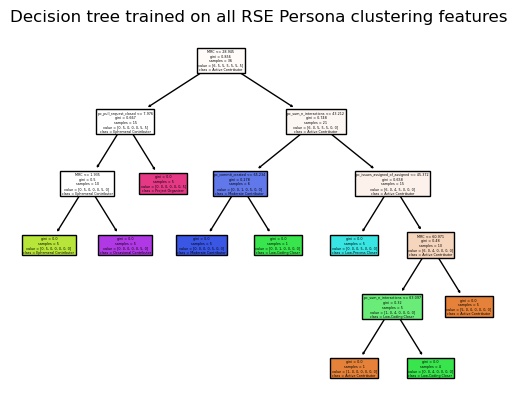

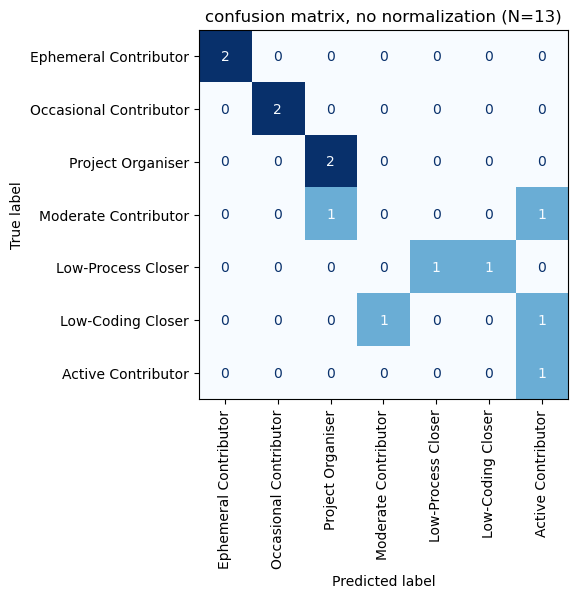

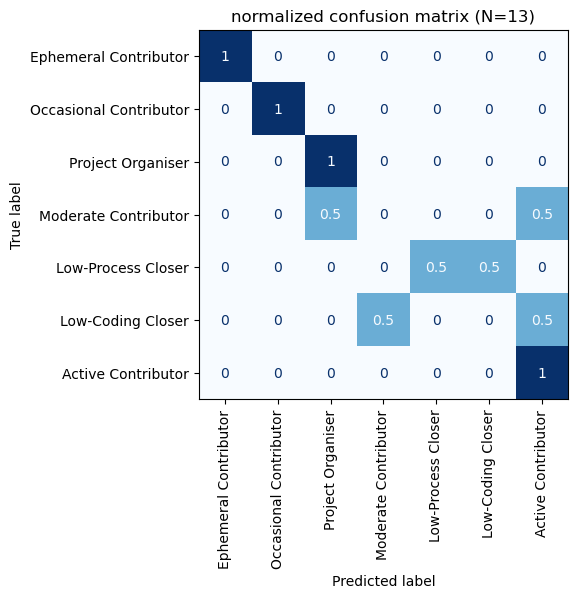

In [1]:
from githubanalysis.analysis.baby_ML_pipeline import ML_pipeline_decision_tree, main

main(
    dataset_name="ML",
    in_notebook=True,
    exists_ok=True,
    logger=None,
    datafile="sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv",
    small_vers=True,
    small_N_appx=50,
    train_pc=0.75,
    test_pc=0.25,
    shuffle_state=True,
    stratify_state=True, # ensuring all personas present in test and training in ~natural ratio
)

attempted to save out to : ../../images/analysis_run_ML_2025-09-19/decision_tree_initial.pdf


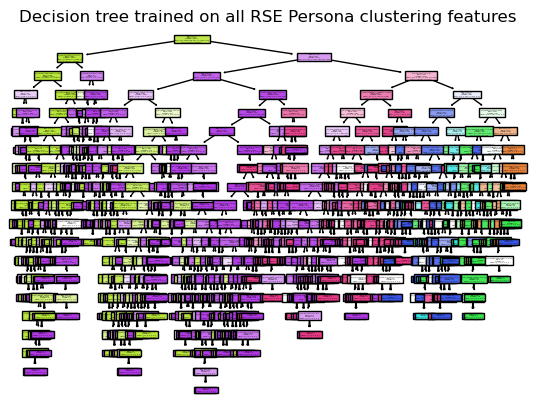

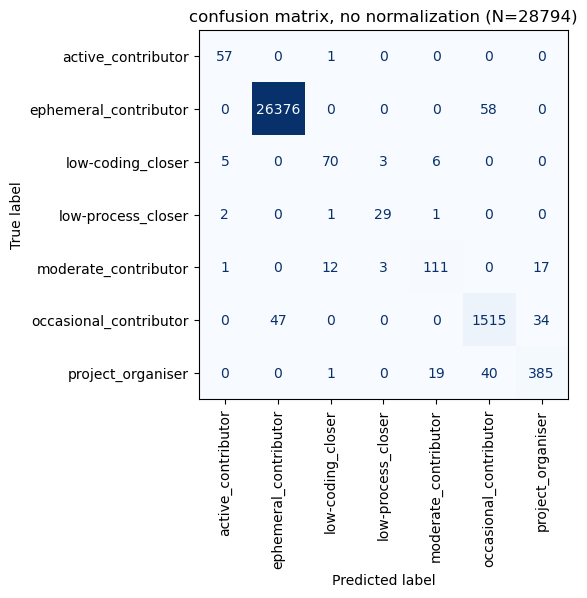

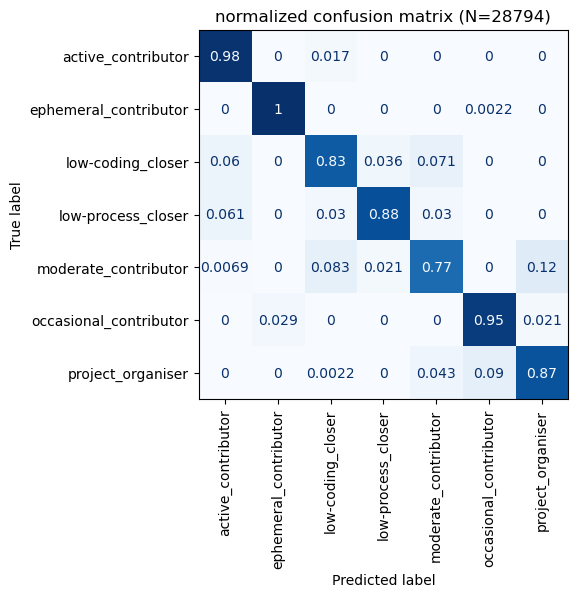

In [5]:
# DECISION-TREE
# 150k dataset of repo-individuals (Set1/45pc)

# run as single function: 
main(
    dataset_name="ML",
    in_notebook=True,
    exists_ok=True,
    logger=None,
    datafile="../../data/sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv",
    small_vers=False,
    small_N_appx=None,
    train_pc=0.75,
    test_pc=0.25,
    shuffle_state=True,
    stratify_state=True, # ensuring all personas present in test and training in ~natural ratio
)

{'memory': None, 'steps': [('clf', DecisionTreeClassifier())], 'verbose': True, 'clf': DecisionTreeClassifier(), 'clf__ccp_alpha': 0.0, 'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__max_features': None, 'clf__max_leaf_nodes': None, 'clf__min_impurity_decrease': 0.0, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__min_weight_fraction_leaf': 0.0, 'clf__random_state': None, 'clf__splitter': 'best'}
[Pipeline] ............... (step 1 of 1) Processing clf, total=   0.0s


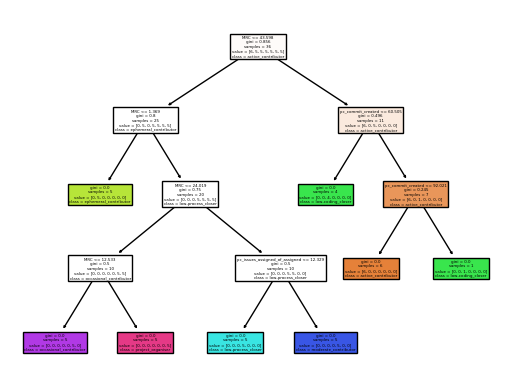

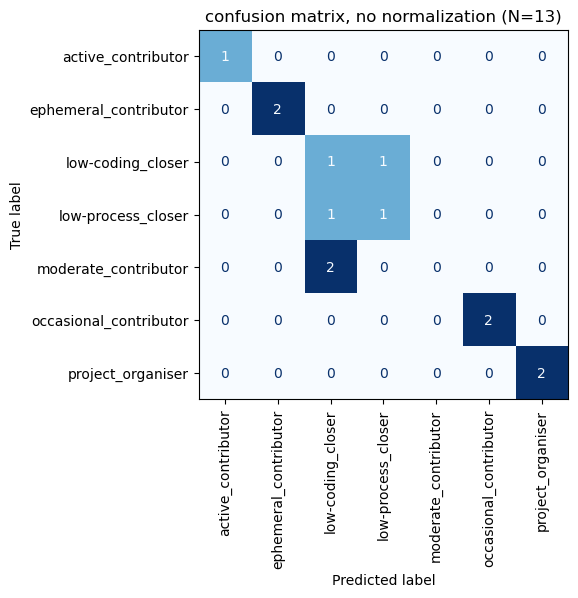

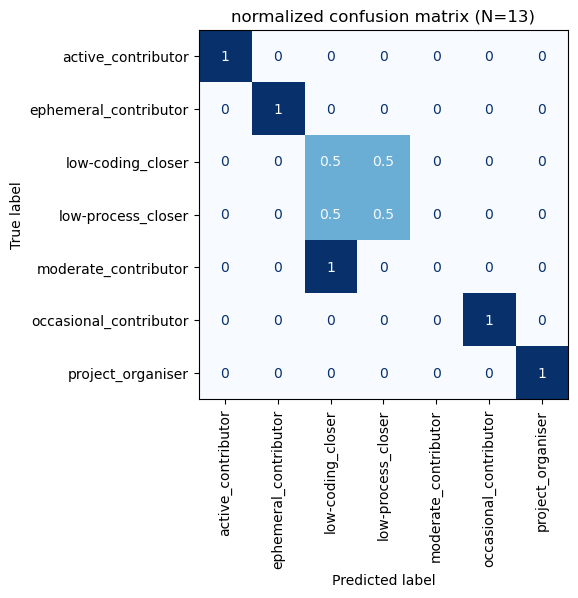

In [71]:
# DECISION-TREE
# small (per-persona-sampled) dataset as 'whole sample', aiming for ~50ish records 

#proto-code for pipeline, pulled into main() run as single function: 

ml_pipeline_dt = ML_pipeline_decision_tree(dataset_name="ML", in_notebook=True, exists_ok=True, logger=None)

# create a pipeline object
pipe = Pipeline(steps=[ # diff twixt make_pipeline()/Pipeline(): https://stackoverflow.com/a/40708448
    #('le', LabelEncoder()),
    ('clf', DecisionTreeClassifier()),
], 
    memory=None, 
    #transform_input=None, # I maybe don't have the updated package version for this (1.6?)
    verbose=True,
)
print(pipe.get_params())

# load the dataset and split it into train and test sets
# read in dataset
datafile = Path(
    ml_pipeline_dt.data_location,
    "sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv",
)
# small (per-persona-sampled) dataset as 'whole sample', aiming for ~50ish records 
classified_df = ml_pipeline_dt.get_data(data_file=datafile, small_vers=True, small_N_appx=50) # 50ish REPO-INDIVIDS ONLY!
RSE_info = ml_pipeline_dt.create_sklearn_format_data(classified_df=classified_df)

# set X (data, no colnames, no personas), y (personas only)
X, y = RSE_info["data"], RSE_info["target"]

# create testing/training dataset
X_train, X_test, y_train, y_test = train_test_split(
                X,
                y,
                #test_size, #=test_pc,  # by (sklearn) default if int: N of samples; if float: proportion of sample; if None and train_size=None also, it uses 25%
                #train_size, #=train_pc,  # by (sklearn) default if int: N of samples; if float: proportion of sample; if None and train_size=None also, it uses 75%
                random_state=42,
                shuffle=True, #shuffle_state,  # True by (sklearn) default
                stratify=RSE_info[
                    "target"
                ],  # same as y; None by (sklearn) default
            )

# fit the whole pipeline
##########

pipe.fit(X_train, y_train)

# plot the decision tree
tree.plot_tree(
    pipe.named_steps['clf'], # use fitted pipe obj created by 'decision_tree step'
    max_depth=5, 
    filled=True,
    feature_names=RSE_info["feature_names"],
    class_names=RSE_info["target_names"],
)

pipe.predict(X_test)
#pipe.le.transform(y_test)

# savefig kwargs
saveout_args = dict(
    dpi=400,
    format="pdf",
    bbox_inches="tight",
)
dataset_size = len(X_test)

# Plot non-normalized confusion matrix
titles_options = [
    (
        f"confusion matrix, no normalization (N={dataset_size})",
        None,
    ),
    (
        f"normalized confusion matrix (N={dataset_size})",
        "true",
    ),  # normalise on True value pcs
]


for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_predictions(
        #y_pred = pipe.predict(X_test),    
        y_pred = ml_pipeline_dt.le.inverse_transform(pipe.predict(X_test)), 
        #y_true= y_test,  
        #self.le.inverse_transform(y_true),  # y_true
        y_true = ml_pipeline_dt.le.inverse_transform(y_test),  # y_pred
        labels=ml_pipeline_dt.le.inverse_transform(pipe.named_steps['clf'].classes_),
        sample_weight=None,
        normalize=normalize,  # 'all': total N samples; 'pred': over predictions; 'true': over true; None: default
        display_labels=None,
        include_values=True,
        xticks_rotation="vertical",
        values_format=None,
        cmap=cmx.Blues,
        ax=None,
        colorbar=False,
        im_kw=None,
        text_kw=None,
    )
    disp.ax_.set_title(title)
#     saveout_name = Path(
#         self.image_write_location,
#         f"confusion_matrix_MRC_tinytestset_normalise{normalize}_{self.current_date_info}.pdf",
#     )
#     plt.savefig(
#         saveout_name,
#         **saveout_args,
#     )
    plt.show()

In [ ]:
# STEP BY STEP BELOW:
# DECISION-TREE

In [1]:
from githubanalysis.analysis.baby_ML_pipeline import ML_pipeline_decision_tree, main

In [3]:
ml_pipeline_dt = ML_pipeline_decision_tree(dataset_name="ML", in_notebook=True, exists_ok=True, logger=None)

In [4]:
from pathlib import Path
# read in dataset
datafile = Path(
    ml_pipeline_dt.data_location,
    "sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv",
)

# small (per-persona-sampled) dataset as 'whole sample', aiming for ~20ish records 
classified_df = ml_pipeline_dt.get_data(data_file=datafile, small_vers=True, small_N_appx=20) 


In [5]:
ml_pipeline_dt.create_sklearn_format_data(classified_df=classified_df)

{'data': array([[ 9.96755880e+01,  1.65745856e+00,  6.29213483e+01,
          1.00000000e+02,  4.28571429e+01,  9.64285714e+01,
          6.14223075e+01,  9.33641225e+01,  7.54424779e+01,
         -6.29047737e+01],
        [ 5.76456311e+01,  9.32203390e+01,  1.00000000e+02,
          1.00000000e+02,  3.33333333e+01,  1.00000000e+02,
          7.68398607e+01,  6.12729234e+01,  6.78832117e+01,
         -9.90677966e+01],
        [ 9.05714286e+01,  2.50000000e+01,  8.62068966e+01,
          9.21052632e+01,  3.12500000e+01,  7.65957447e+01,
          6.50267177e+01,  7.50000000e+01,  6.16487455e+01,
         -8.59568966e+01],
        [ 4.16666667e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  1.35135135e+00,  0.00000000e+00,
          1.10360360e+00,  7.24637681e-01,  7.35294118e-01,
          0.00000000e+00],
        [ 6.62397880e-01,  1.41043724e-01,  0.00000000e+00,
          0.00000000e+00,  1.17994100e+00,  0.00000000e+00,
          3.96676521e-01,  5.46309236e-01,  

In [6]:
clf, X_train, X_test, y_train, y_test = ml_pipeline_dt.do_decision_tree()

attempted to save out to : ../../images/analysis_run_ML_2025-09-19/decision_tree_initial.pdf


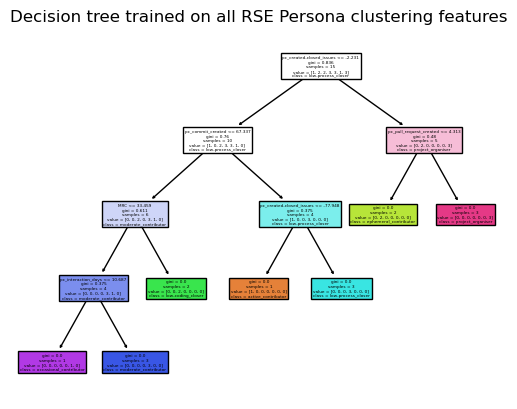

In [7]:
ml_pipeline_dt.plot_decision_tree(clf)

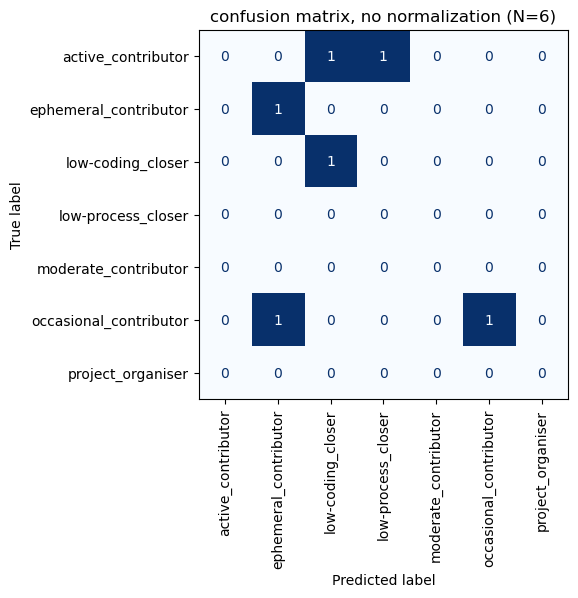

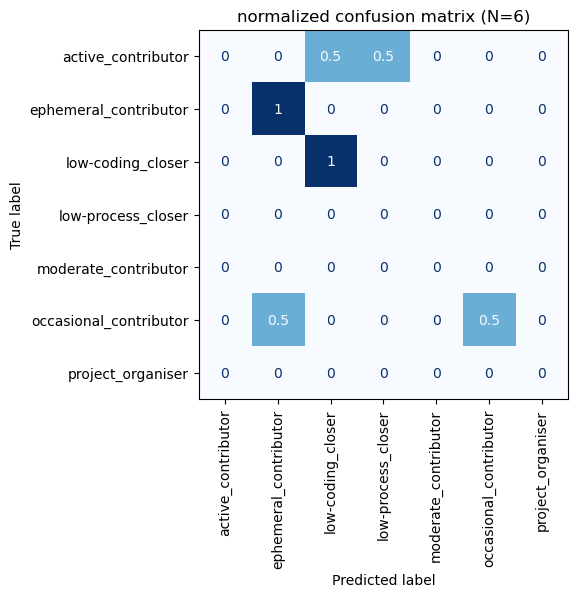

In [8]:
ml_pipeline_dt.run_predictor(clf, X_test, y_test, classified_df)